# Classificação na prática
## Dos exemplos rotulados à interpretação dos erros

**Objetivo:** treinar classificadores simples, distinguir classificação binária,
multiclasse e multirrótulo e justificar a escolha das métricas.

Na classificação supervisionada, aprendemos com exemplos que já têm uma
resposta conhecida para prever as classes de novos exemplos.
Vamos explorar os dados, treinar modelos e interpretar seus acertos e erros.
Ao longo dos exemplos, observe como o tipo de problema e a escolha das
métricas influenciam a avaliação.

| Problema | Dados | O que prever? |
|---|---|---|
| Binário | Wisconsin Breast Cancer | Uma entre duas classes: benigno ou maligno |
| Multiclasse | Iris | Uma entre três espécies |
| Multirrótulo | Digits, com alvos derivados | Se um dígito é ímpar e se é maior ou igual a 5 |

Os dados vêm com o scikit-learn e não exigem download separado.
O Digits contém imagens de dígitos manuscritos com resolução de 8 × 8 pixels.

**Como usar:** execute as células na ordem. Antes de cada resultado, tente
antecipar o que ele mostrará. Responda aos exercícios usando as tabelas,
os gráficos e as contagens de acertos e erros para justificar suas respostas.

### Preparação

**No Google Colab:** abra o notebook pelo botão **Abrir no Colab** no
[README do projeto](https://github.com/samirbraga/aula-classificacao#readme).
Para guardar suas alterações, use **Arquivo → Salvar uma cópia no Drive**.

**No computador:** na pasta do projeto, execute `uv sync --locked`.
No VS Code, selecione o Python da pasta `.venv` como kernel do notebook.
O uv instala as dependências e a versão de Python definidas no projeto.

A primeira célula importa as bibliotecas e mostra suas versões.

In [58]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, load_iris, load_digits, make_classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
    hamming_loss,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)

SEMENTE = 42
plt.rcParams.update({'figure.figsize': (7, 4), 'font.size': 11})
pd.set_option('display.precision', 3)
display(
    pd.Series(
        {
            'Python': sys.version.split()[0],
            'scikit-learn': sklearn.__version__,
            'numpy': np.__version__,
            'pandas': pd.__version__,
            'matplotlib': matplotlib.__version__,
        }, 
        name='Versão',
    ),
)

Python          3.14.6
scikit-learn     1.9.1
numpy            2.5.3
pandas           3.0.5
matplotlib      3.11.2
Name: Versão, dtype: str

## 1. Antes dos modelos: o que significa acertar?

Vamos analisar um classificador em um conjunto de 2109 observações.
A classe de interesse é a positiva,
codificada como `1`. No scikit-learn, as **linhas representam valores reais** e
as **colunas, valores previstos**. Fixamos a ordem `[0, 1]` explicitamente:

| Real / previsto | 0: negativo | 1: positivo |
|---|---:|---:|
| 0: negativo | VN = 2029 | FP = 3 |
| 1: positivo | FN = 65 | VP = 12 |

**VP** e **VN** são verdadeiros positivos e verdadeiros negativos: previsões
corretas. **FP** são falsos positivos: negativos previstos como positivos.
**FN** são falsos negativos: positivos previstos como negativos.

**Exercício 1.** Este classificador é bom para encontrar os positivos?
Responda primeiro olhando apenas para as contagens, sem calcular a acurácia.

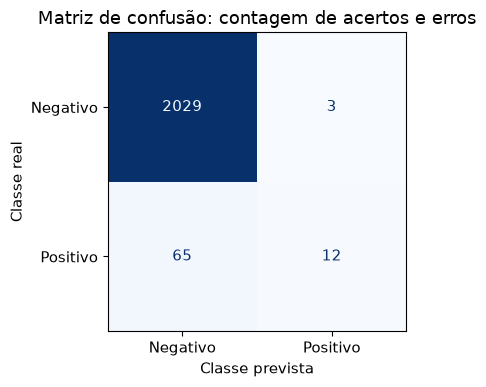

Acurácia                  0.968
Precisão                  0.800
Recall / sensibilidade    0.156
Especificidade            0.999
F1                        0.261
Acurácia balanceada       0.577
Name: Valor, dtype: float64

In [59]:
# Um par (real, previsto) para cada uma das 2109 observações do exemplo.
real_exemplo = np.repeat([0, 0, 1, 1], [2029, 3, 65, 12])
previsto_exemplo = np.repeat([0, 1, 0, 1], [2029, 3, 65, 12])
matriz_exemplo = confusion_matrix(real_exemplo, previsto_exemplo, labels=[0, 1])
ConfusionMatrixDisplay(matriz_exemplo, display_labels=['Negativo', 'Positivo']).plot(
    cmap='Blues', colorbar=False
)
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.title('Matriz de confusão: contagem de acertos e erros')
plt.tight_layout()
plt.show()

vn, fp, fn, vp = matriz_exemplo.ravel()
display(
    pd.Series(
        {
            'Acurácia': (vp + vn) / matriz_exemplo.sum(),
            'Precisão': vp / (vp + fp),
            'Recall / sensibilidade': vp / (vp + fn),
            'Especificidade': vn / (vn + fp),
            'F1': 2 * vp / (2 * vp + fp + fn),
            'Acurácia balanceada': ((vp / (vp + fn)) + (vn / (vn + fp))) / 2,
        }, 
        name='Valor',
    ),
)

### Cada métrica responde a uma pergunta

| Métrica | Pergunta | Uso e limite |
|---|---|---|
| Acurácia | Que fração de todos os exemplos acertei? | Visão geral; pode esconder erros na classe rara. |
| Precisão | Dos positivos que anunciei, quantos eram positivos? | Útil quando falsos alarmes custam caro. |
| Recall / sensibilidade | Dos positivos reais, quantos encontrei? | Útil quando deixar um positivo passar custa caro. |
| Especificidade | Dos negativos reais, quantos reconheci? | Mostra a capacidade de rejeitar negativos. |
| F1 | Como resumir precisão e recall? | Média harmônica; não usa VN nem representa qualquer custo de erro. |
| Acurácia balanceada | Como fui dando o mesmo peso a cada classe? | Média dos recalls das classes; ajuda no desbalanceamento. |

$$\mathrm{Precisão}=\frac{VP}{VP+FP},\quad
\mathrm{Recall}=\frac{VP}{VP+FN},\quad
F_1=\frac{2VP}{2VP+FP+FN}.$$

Neste exemplo, há muitos negativos. Uma acurácia alta pode coexistir com
recall baixo. Precisão e acurácia são conceitos diferentes.

In [60]:
def metricas_binarias(y_real, y_previsto):
    """Resumo para os problemas desta aula: negativo=0 e positivo=1."""
    vn, fp, fn, vp = confusion_matrix(y_real, y_previsto, labels=[0, 1]).ravel()
    return {
        'acurácia': accuracy_score(y_real, y_previsto),
        'precisão': precision_score(y_real, y_previsto, zero_division=0),
        'recall': recall_score(y_real, y_previsto, zero_division=0),
        'especificidade': vn / (vn + fp) if vn + fp else np.nan,
        'F1': f1_score(y_real, y_previsto, zero_division=0),
        'acurácia balanceada': balanced_accuracy_score(y_real, y_previsto),
    }

display(
    pd.DataFrame({
        'Classificador do exemplo': metricas_binarias(real_exemplo, previsto_exemplo),
        'Sempre negativo': metricas_binarias(real_exemplo, np.zeros_like(real_exemplo)),
    }).T,
)

,acurácia,precisão,recall,especificidade,F1,acurácia balanceada
Classificador do exemplo,0.968,0.8,0.156,0.999,0.261,0.577
Sempre negativo,0.963,0.0,0.000,1.000,0.000,0.500


Quando um modelo nunca prevê positivos, a precisão fica indefinida
(`VP + FP = 0`). Usamos `zero_division=0` para registrar zero nessa situação;
isso é uma convenção de apresentação, e não evidência de precisão medida.

**Exercício 2.** Compare “sempre negativo” com o classificador do exemplo.
Qual vence em acurácia? Qual encontra mais positivos? Que problema essa
comparação revela?

## 2. Classificação binária com regressão logística

### 2.1. Conhecendo os dados antes de treinar

O **Breast Cancer Wisconsin (Diagnostic)** contém 569 exemplos. Cada linha
representa um caso, descrito por medidas de núcleos celulares obtidas de uma
imagem de material coletado por punção de uma massa mamária. A versão carregada
pelo scikit-learn traz uma **tabela de medidas**, sem as imagens originais.

São **30 atributos numéricos** e uma classe por caso: benigno ou maligno.
O objetivo do modelo será receber essas medidas e prever a classe.
A descrição dos atributos pode ser consultada em `dados_bin.DESCR` e na
[documentação do dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset).

**Atenção à codificação:** no dataset original, `0` significa maligno e `1`,
benigno. Vamos recodificar para que **positivo = maligno = 1**. Assim, recall
responde “que fração dos exemplos malignos o modelo encontrou?”.

**X** é a tabela de atributos; **y** é a resposta que queremos aprender a prever.
O alvo não entra nas colunas de X.

In [61]:
dados_bin = load_breast_cancer(as_frame=True)
X_bin = dados_bin.data
y_bin = (dados_bin.target == 0).astype(int).rename('maligno')

display(
    pd.Series(
        {
            'casos (linhas)': X_bin.shape[0],
            'atributos (colunas de X)': X_bin.shape[1],
            'classes distintas': y_bin.nunique(),
            'atributos numéricos': X_bin.select_dtypes(include='number').shape[1],
            'valores ausentes em X': int(X_bin.isna().sum().sum()),
        },
        name='Visão geral',
    )
)

casos (linhas)              569
atributos (colunas de X)     30
classes distintas             2
atributos numéricos          30
valores ausentes em X         0
Name: Visão geral, dtype: int64

### O que as colunas medem?

Há dez características básicas dos núcleos celulares:

| Nome no dataset | Significado |
|---|---|
| `radius` | Raio: distância do centro aos pontos do contorno |
| `texture` | Textura: variação dos tons de cinza |
| `perimeter` | Comprimento do contorno |
| `area` | Área do núcleo |
| `smoothness` | Variações locais no raio, relacionadas à regularidade do contorno |
| `compactness` | Medida que relaciona perímetro e área |
| `concavity` | Intensidade das partes côncavas do contorno |
| `concave points` | Quantificação das partes côncavas do contorno |
| `symmetry` | Simetria |
| `fractal dimension` | Medida de complexidade do contorno |

Cada característica aparece em três resumos: **média** (`mean`), **erro padrão**
(`error`) e **média dos três maiores valores** (`worst`). Assim, temos
**10 características × 3 resumos = 30 atributos**. `worst` não é uma classe
nem uma previsão: faz parte da descrição numérica do caso.

Por exemplo, `mean radius`, `radius error` e `worst radius` são três colunas
diferentes relacionadas ao raio. Usaremos os valores na escala fornecida
pelo dataset. A descrição consultada não especifica uma unidade física,
como milímetros, para essas medidas.

In [62]:
# Todos os 30 nomes, agrupados pelos três tipos de resumo.
display(
    pd.DataFrame({
        'Média': X_bin.columns[:10],
        'Erro padrão': X_bin.columns[10:20],
        'Média dos três maiores': X_bin.columns[20:30],
    }),
)

,Média,Erro padrão,Média dos três maiores
0,mean radius,radius error,worst radius
1,mean texture,texture error,worst texture
2,mean perimeter,perimeter error,worst perimeter
3,mean area,area error,worst area
4,mean smoothness,smoothness error,worst smoothness
5,mean compactness,compactness error,worst compactness
6,mean concavity,concavity error,worst concavity
7,mean concave points,concave points error,worst concave points
8,mean symmetry,symmetry error,worst symmetry
9,mean fractal dimension,fractal dimension error,worst fractal dimension


### Uma amostra de linhas, com a resposta ao lado

A tabela abaixo reúne seis casos sorteados, cinco atributos selecionados
para leitura e o alvo. O índice à esquerda identifica a linha na tabela;
ele não é um atributo usado no treinamento. O modelo usará **todos os 30
atributos**, não apenas os cinco exibidos.

`classe` traduz o alvo para texto. `y: maligno=1` é a codificação que usaremos.
Essas duas colunas são mostradas ao lado dos atributos apenas para explorar
os dados; **não serão acrescentadas a X**.

In [63]:
colunas_exemplo = ['mean radius', 'mean texture', 'mean area', 'radius error', 'worst radius']
amostra_bin = X_bin[colunas_exemplo].sample(n=6, random_state=SEMENTE).copy()
amostra_bin['classe'] = y_bin.loc[amostra_bin.index].map({0: 'Benigno', 1: 'Maligno'})
amostra_bin['y: maligno=1'] = y_bin.loc[amostra_bin.index]
display(amostra_bin)

# Leia um caso em palavras para conectar a linha ao problema de classificação.
caso = amostra_bin.iloc[0]
print(
    f"Na primeira linha exibida, o raio médio é {caso['mean radius']:.2f}, "
    f"a textura média é {caso['mean texture']:.2f} "
    f"e a classe conhecida é {caso['classe']}."
)

,mean radius,mean texture,mean area,radius error,worst radius,classe,y: maligno=1
204,12.47,18.60,481.9,0.396,14.97,Benigno,0
70,18.94,21.31,1130.0,0.789,24.86,Maligno,1
131,15.46,19.48,748.9,0.474,19.26,Maligno,1
431,12.40,17.68,467.8,0.177,12.88,Benigno,0
540,11.54,14.44,402.9,0.278,12.26,Benigno,0
567,20.60,29.33,1265.0,0.726,25.74,Maligno,1


Na primeira linha exibida, o raio médio é 12.47, a textura média é 18.60 e a classe conhecida é Benigno.


### Quantos casos há de cada classe? As medidas têm a mesma escala?

As contagens indicam o equilíbrio entre classes. Já mínimo, média e máximo
ajudam a perceber a escala dos atributos. Observe, por exemplo, a diferença
de ordem de grandeza entre `mean area` e `mean smoothness`.
Essa diferença motiva a padronização que será aplicada **apenas após separar
os conjuntos**, aprendendo as estatísticas no treino.

,casos,percentual (%)
maligno,,
Benigno,357,62.742
Maligno,212,37.258


,min,mean,max
mean radius,6.981,14.127,28.110
mean texture,9.710,19.290,39.280
mean area,143.500,654.889,2501.000
mean smoothness,0.053,0.096,0.163


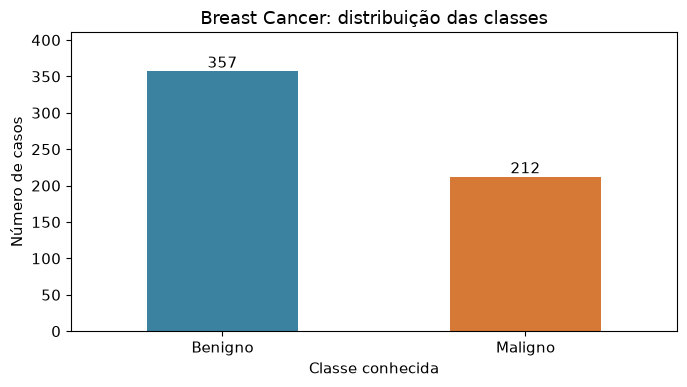

In [64]:
contagem_bin = y_bin.value_counts().sort_index().rename(index={0: 'Benigno', 1: 'Maligno'})
display(
    pd.DataFrame({
        'casos': contagem_bin,
        'percentual (%)': 100 * contagem_bin / contagem_bin.sum(),
    }),
)
display(
    X_bin[['mean radius', 'mean texture', 'mean area', 'mean smoothness']]
    .describe()
    .T[['min', 'mean', 'max']]
)

ax = contagem_bin.plot.bar(color=['#3B82A0', '#D77936'], rot=0)
ax.bar_label(ax.containers[0])
ax.set(xlabel='Classe conhecida', ylabel='Número de casos', title='Breast Cancer: distribuição das classes')
ax.set_ylim(0, contagem_bin.max() * 1.15)
plt.tight_layout()
plt.show()

**Para discutir antes de treinar:** o que representa uma linha? Quais colunas
são entradas e qual é a resposta? A classe mais frequente é também a classe
positiva? Se o modelo respondesse sempre “benigno”, quantos casos acertaria?

A exploração acima descreve o conjunto. As escolhas de modelos, parâmetros
e limiares serão feitas com treino e validação, mantendo o teste reservado.

### Treino, validação e teste

- **Treino (~60%):** aprender os parâmetros do modelo e da padronização.
- **Validação (~20%):** comparar modelos e explorar decisões como o limiar.
- **Teste (~20%):** avaliar uma escolha já concluída em dados reservados.

`stratify=y` mantém aproximadamente as proporções das classes em cada parte.
`random_state` torna o sorteio reproduzível; não melhora o modelo.

A validação permite escolher entre modelos antes da avaliação final.
Neste conjunto, usaremos uma divisão aleatória estratificada. Dados
temporais ou com grupos de observações relacionadas exigem uma estratégia
de divisão que respeite essas relações.

In [65]:
X_bin_dev, X_bin_teste, y_bin_dev, y_bin_teste = train_test_split(
    X_bin, y_bin, test_size=0.20, stratify=y_bin, random_state=SEMENTE
)
X_bin_treino, X_bin_val, y_bin_treino, y_bin_val = train_test_split(
    X_bin_dev, y_bin_dev, test_size=0.25, stratify=y_bin_dev, random_state=SEMENTE
)

display(
    pd.DataFrame(
        {
            'exemplos': [len(y_bin_treino), len(y_bin_val), len(y_bin_teste)],
            'proporção positiva': [y_bin_treino.mean(), y_bin_val.mean(), y_bin_teste.mean()],
        },
        index=['treino', 'validação', 'teste'],
    ),
)

,exemplos,proporção positiva
treino,341,0.372
validação,114,0.377
teste,114,0.368


### `fit`, `predict` e `predict_proba`

Apesar do nome, `LogisticRegression` é um **classificador**. No caso binário,
transforma uma combinação dos atributos em uma probabilidade estimada:

$$p(y=1\mid x)=\frac{1}{1+e^{-(b+w_1x_1+\cdots+w_px_p)}}.$$

- `fit(X, y)` aprende com exemplos rotulados.
- `predict(X)` retorna classes.
- `predict_proba(X)` retorna uma coluna de probabilidades por classe.

As medidas de X têm escalas diferentes. `StandardScaler` usa a média e o
desvio-padrão do **treino** para padronizar os atributos. O `Pipeline` aplica
o mesmo tratamento aos demais conjuntos, sem aprender suas estatísticas.

In [66]:
logistica = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
logistica.fit(X_bin_treino, y_bin_treino)
pred_bin_val = logistica.predict(X_bin_val)

# A ordem das colunas de predict_proba é dada por classes_.
indice_positivo = list(logistica.classes_).index(1)
prob_bin_val = logistica.predict_proba(X_bin_val)[:, indice_positivo]
display(
    pd.DataFrame(
        {
            'real (1=maligno)': y_bin_val.to_numpy(),
            'previsto': pred_bin_val,
            'probabilidade estimada de maligno': prob_bin_val,
        },
    ).head(10),
)
display(
    pd.Series(
        metricas_binarias(y_bin_val, pred_bin_val),
        name='Validação',
    ),
)

,real (1=maligno),previsto,probabilidade estimada de maligno
0,0,0,1.969e-02
1,1,1,1.000e+00
2,0,0,8.783e-07
3,0,0,1.263e-02
4,0,0,1.126e-02
5,0,0,1.178e-02
6,0,0,4.792e-02
7,1,1,1.000e+00
8,1,1,9.996e-01
9,1,0,1.094e-01


acurácia               0.974
precisão               0.955
recall                 0.977
especificidade         0.972
F1                     0.966
acurácia balanceada    0.974
Name: Validação, dtype: float64

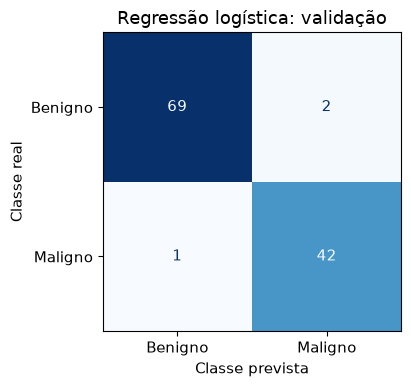

In [67]:
ConfusionMatrixDisplay.from_predictions(
    y_bin_val, pred_bin_val, labels=[0, 1],
    display_labels=['Benigno', 'Maligno'], cmap='Blues', colorbar=False
)
plt.title('Regressão logística: validação')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.tight_layout()
plt.show()

**Exercício 3.** Identifique um falso positivo e um falso negativo na matriz.
Explique cada erro usando os nomes das classes, em vez de apenas “0” e “1”.

### Probabilidade e decisão são coisas diferentes

Vamos declarar positivo quando a probabilidade estimada for maior ou igual
ao limiar. Ao reduzir esse limiar, podemos encontrar mais positivos, mas
também produzir mais falsos positivos. A precisão não precisa variar de
forma monotônica em uma amostra finita.

Explore os limiares **na validação**. A comparação seguinte usa a regra
de decisão padrão de cada classificador. Probabilidades estimadas não
são garantias nem necessariamente estão bem calibradas.

,positivos previstos,acurácia,precisão,recall,especificidade,F1,acurácia balanceada
limiar,,,,,,,
0.05,60,0.851,0.717,1.000,0.761,0.835,0.880
0.50,44,0.974,0.955,0.977,0.972,0.966,0.974
0.95,38,0.956,1.000,0.884,1.000,0.938,0.942


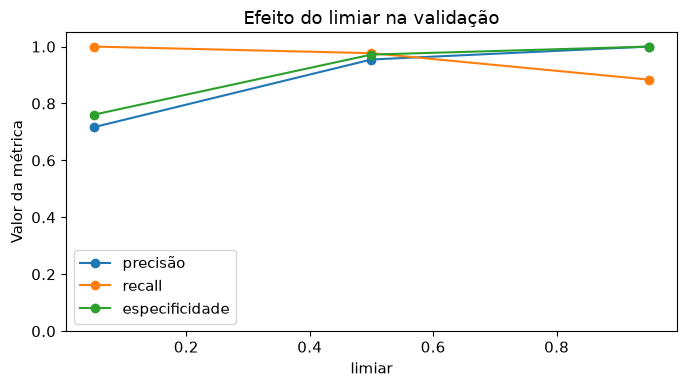

In [68]:
linhas_limiar = []
for limiar in [0.05, 0.5, 0.95]:
    previsao = (prob_bin_val >= limiar).astype(int)
    linhas_limiar.append({
        'limiar': limiar,
        'positivos previstos': int(previsao.sum()),
        **metricas_binarias(y_bin_val, previsao),
    })
tabela_limiar = pd.DataFrame(linhas_limiar).set_index('limiar')
display(tabela_limiar)
tabela_limiar[['precisão', 'recall', 'especificidade']].plot(marker='o', ylim=(0, 1.05))
plt.title('Efeito do limiar na validação')
plt.ylabel('Valor da métrica')
plt.tight_layout()
plt.show()

**Exercício 4.** Qual limiar encontrou mais positivos? Como mudou a
especificidade? Se o objetivo fosse escolher um limiar, em qual conjunto
você faria essa escolha e em qual avaliaria o resultado final?

## 3. Comparar alguns modelos clássicos

| Modelo | Intuição | Escolha nesta prática |
|---|---|---|
| Dummy | Sempre responde a classe mais frequente no treino | Referência mínima de comparação |
| Regressão logística | Combina atributos para estimar probabilidades | Padronização e até 2000 iterações |
| k-NN | Consulta os exemplos de treino mais próximos | 5 vizinhos e padronização |
| Árvore de decisão | Aprende uma sequência de perguntas | Profundidade máxima 3 |
| Naive Bayes gaussiano | Combina distribuições dos atributos por classe | Hipóteses gaussianas e independência condicional |

Esses modelos aprendem de maneiras diferentes: a árvore cria regras de
decisão, o k-NN usa proximidade entre exemplos e o Naive Bayes combina
probabilidades sob hipóteses simplificadoras.

Todos recebem os mesmos exemplos de treino e validação. O critério de
escolha será o **F1 da classe positiva**, definido antes de observar os
resultados. Isso não significa que F1 seja a melhor métrica para todo problema.

In [69]:
modelos = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Regressão logística': make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000)
    ),
    'k-NN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Árvore': DecisionTreeClassifier(max_depth=3, random_state=SEMENTE),
    'Naive Bayes': GaussianNB(),
}

resultados_bin = []
for nome, modelo in modelos.items():
    candidato = clone(modelo)
    candidato.fit(X_bin_treino, y_bin_treino)
    previsao = candidato.predict(X_bin_val)
    resultados_bin.append({'modelo': nome, **metricas_binarias(y_bin_val, previsao)})

tabela_bin = pd.DataFrame(resultados_bin).set_index('modelo')
display(tabela_bin.sort_values('F1', ascending=False))

,acurácia,precisão,recall,especificidade,F1,acurácia balanceada
modelo,,,,,,
Regressão logística,0.974,0.955,0.977,0.972,0.966,0.974
k-NN,0.974,1.000,0.930,1.000,0.964,0.965
Naive Bayes,0.956,0.952,0.930,0.972,0.941,0.951
Árvore,0.921,0.905,0.884,0.944,0.894,0.914
Dummy,0.623,0.000,0.000,1.000,0.000,0.500


### Uma avaliação final

Escolhemos o maior F1 de validação. Em empate, usamos o primeiro modelo na
ordem declarada. Reajustamos essa configuração em **treino + validação** e
avaliamos no teste. A padronização também é reaprendida somente nesses dados.

Depois de abrir o teste, não o usamos para trocar modelos ou parâmetros.
O resultado é uma estimativa para esta divisão, não um ranking universal.

In [70]:
nome_bin_final = tabela_bin['F1'].idxmax()
modelo_bin_final = clone(modelos[nome_bin_final]).fit(X_bin_dev, y_bin_dev)
pred_bin_teste = modelo_bin_final.predict(X_bin_teste)
print('Escolhido pela validação:', nome_bin_final)
display(pd.Series(metricas_binarias(y_bin_teste, pred_bin_teste), name='Teste final'))
print(
    classification_report(
        y_bin_teste, pred_bin_teste, 
        labels=[0, 1],
        target_names=['Benigno', 'Maligno'], 
        zero_division=0,
    ),
)

Escolhido pela validação: Regressão logística


acurácia               0.965
precisão               0.975
recall                 0.929
especificidade         0.986
F1                     0.951
acurácia balanceada    0.957
Name: Teste final, dtype: float64

              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**Exercício 5.** O modelo com maior acurácia de validação também teve maior
F1? Se isso acontecer, as métricas medem a mesma coisa? O conjunto de teste
precisa ter exatamente o mesmo desempenho da validação?

## 4. Multiclasse: uma entre três espécies de Iris

O Iris contém 150 flores, quatro medidas por flor e três espécies. Cada flor
pertence a **uma única classe**. Usaremos os quatro atributos no treinamento;
o gráfico abaixo mostra apenas duas medidas para facilitar a visualização.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


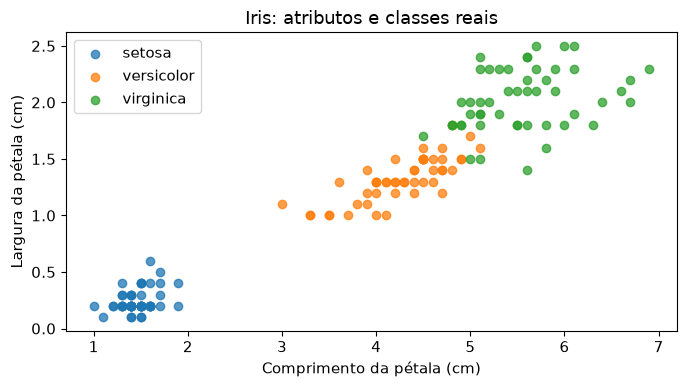

In [71]:
iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target
display(X_iris.head())
for classe, nome in enumerate(iris.target_names):
    grupo = X_iris[y_iris == classe]
    plt.scatter(grupo.iloc[:, 2], grupo.iloc[:, 3], label=nome, alpha=0.75)
plt.xlabel('Comprimento da pétala (cm)')
plt.ylabel('Largura da pétala (cm)')
plt.title('Iris: atributos e classes reais')
plt.legend()
plt.tight_layout()
plt.show()

### Precisão, recall e F1 com mais de duas classes

Calculamos cada métrica tratando uma classe de cada vez como “positiva” e
as demais como “negativas”. Para resumir:

- **Macro:** calcula a métrica por classe e tira a média simples.
- **Weighted:** pondera as métricas pelo número de exemplos reais de cada classe.
- **Micro:** soma VP, FP e FN das classes antes de calcular a métrica.

Com uma única classe por exemplo e todas as classes incluídas, F1 micro é
igual à acurácia. F1 macro dá o mesmo peso a cada classe. Ele é a **média
dos F1 por classe**, não o F1 calculado a partir das médias de precisão e recall.

O Iris tem o mesmo número de exemplos por classe. Quando os suportes
são iguais, as médias macro e weighted coincidem. Observe essa relação
na tabela abaixo. Escolheremos o modelo pelo **F1 macro de validação**.

In [72]:
X_iris_dev, X_iris_teste, y_iris_dev, y_iris_teste = train_test_split(
    X_iris, y_iris, test_size=0.20, stratify=y_iris, random_state=SEMENTE
)
X_iris_treino, X_iris_val, y_iris_treino, y_iris_val = train_test_split(
    X_iris_dev, y_iris_dev, test_size=0.25, stratify=y_iris_dev, random_state=SEMENTE
)
resultados_iris = []
for nome, modelo in modelos.items():
    candidato = clone(modelo).fit(X_iris_treino, y_iris_treino)
    previsao = candidato.predict(X_iris_val)
    resultados_iris.append({
        'modelo': nome,
        'acurácia': accuracy_score(y_iris_val, previsao),
        'F1 macro': f1_score(y_iris_val, previsao, average='macro', zero_division=0),
        'F1 weighted': f1_score(y_iris_val, previsao, average='weighted', zero_division=0),
    })
tabela_iris = pd.DataFrame(resultados_iris).set_index('modelo')
display(tabela_iris.sort_values('F1 macro', ascending=False))

,acurácia,F1 macro,F1 weighted
modelo,,,
Regressão logística,0.933,0.933,0.933
Naive Bayes,0.933,0.933,0.933
k-NN,0.933,0.933,0.933
Árvore,0.900,0.900,0.900
Dummy,0.333,0.167,0.167


Escolhido pela validação: Regressão logística
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



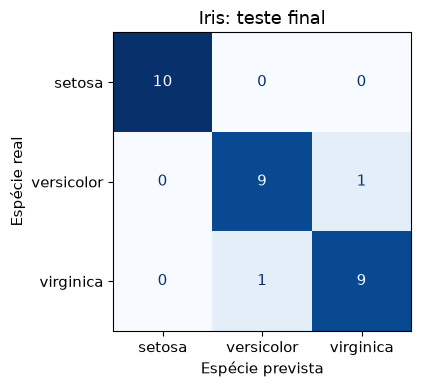

In [73]:
nome_iris_final = tabela_iris['F1 macro'].idxmax()
modelo_iris_final = clone(modelos[nome_iris_final]).fit(X_iris_dev, y_iris_dev)
pred_iris_teste = modelo_iris_final.predict(X_iris_teste)
print('Escolhido pela validação:', nome_iris_final)
print(classification_report(
    y_iris_teste, pred_iris_teste, labels=[0, 1, 2],
    target_names=iris.target_names, zero_division=0
))
ConfusionMatrixDisplay.from_predictions(
    y_iris_teste, pred_iris_teste, labels=[0, 1, 2],
    display_labels=iris.target_names, cmap='Blues', colorbar=False
)
plt.xlabel('Espécie prevista')
plt.ylabel('Espécie real')
plt.title('Iris: teste final')
plt.tight_layout()
plt.show()

**Exercício 6.** Quais espécies foram confundidas? Se não houver erros neste
teste, isso garante que o modelo nunca errará? Quantos exemplos de cada
espécie sustentam a conclusão? Observe a coluna `support`.

## 5. Multirrótulo: duas perguntas para a mesma imagem

O dataset Digits contém 1797 imagens 8 × 8. Seu alvo original é uma classe
de 0 a 9. Vamos derivar dois alvos binários para formular um problema multirrótulo:

1. O dígito é **ímpar**?
2. O dígito é **maior ou igual a 5**?

O dígito 7 recebe `[1, 1]`; o 2 recebe `[0, 0]`; o 6 recebe `[0, 1]`.
Os rótulos podem coexistir. Eles são construídos a partir da anotação correta,
mas o **modelo recebe apenas os 64 pixels**, sem acesso ao dígito anotado.

Agora, cada imagem recebe duas respostas binárias, que podem ser positivas
ao mesmo tempo. No problema original, cada imagem recebia uma única
classe entre os dez dígitos.

,dígito original,ímpar,maior ou igual a 5
0,0,0,0
1,1,1,0
2,2,0,0
3,3,1,0
4,4,0,0
5,5,1,1
6,6,0,1
7,7,1,1
8,8,0,1
9,9,1,1


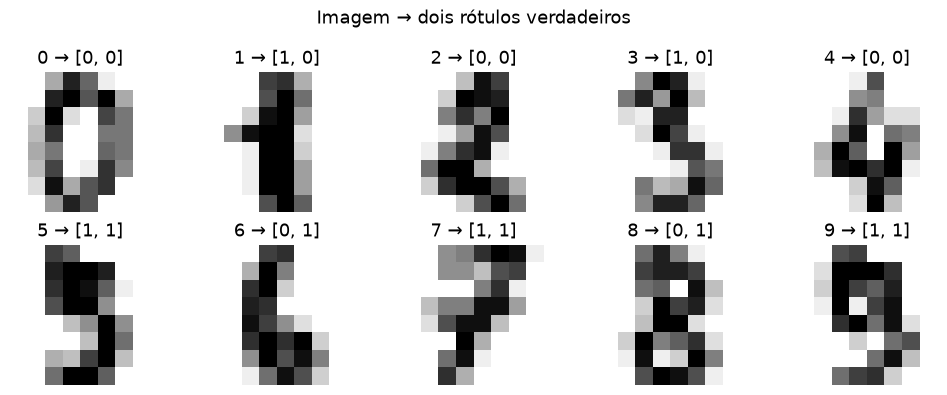

In [74]:
digitos = load_digits()
X_dig = digitos.data
Y_dig = np.column_stack([digitos.target % 2 == 1, digitos.target >= 5]).astype(int)
nomes_rotulos = ['Ímpar', 'Maior ou igual a 5']

display(
    pd.DataFrame({
        'dígito original': digitos.target[:10],
        'ímpar': Y_dig[:10, 0],
        'maior ou igual a 5': Y_dig[:10, 1],
    }),
)
fig, eixos = plt.subplots(2, 5, figsize=(10, 4))
for i, eixo in enumerate(eixos.ravel()):
    eixo.imshow(digitos.images[i], cmap='gray_r')
    eixo.set_title(f'{digitos.target[i]} → {Y_dig[i].tolist()}')
    eixo.axis('off')
fig.suptitle('Imagem → dois rótulos verdadeiros')
plt.tight_layout()
plt.show()

`OneVsRestClassifier` ajusta uma regressão logística por rótulo.
O k-NN já aceita uma matriz de alvos multirrótulo. Vamos comparar os dois
na validação e escolher pelo F1 macro entre os rótulos.

Neste exemplo, estratificamos pelo **dígito original**, que é conhecido na
preparação do dataset. Isso mantém aproximadamente sua distribuição e a
dos rótulos derivados. Não é uma solução geral de estratificação multirrótulo.

In [75]:
idx_dig_dev, idx_dig_teste = train_test_split(
    np.arange(len(X_dig)), test_size=0.20,
    stratify=digitos.target, random_state=SEMENTE
)
idx_dig_treino, idx_dig_val = train_test_split(
    idx_dig_dev, test_size=0.25,
    stratify=digitos.target[idx_dig_dev], random_state=SEMENTE
)
modelos_multi = {
    'Logística por rótulo': make_pipeline(
        StandardScaler(), OneVsRestClassifier(LogisticRegression(max_iter=2000)),
    ),
    'k-NN': make_pipeline(
        StandardScaler(), KNeighborsClassifier(n_neighbors=5),
    ),
}

def metricas_multirrotulo(y_real, y_previsto):
    return {
        'acerto de todos os rótulos': accuracy_score(y_real, y_previsto),
        'Hamming loss': hamming_loss(y_real, y_previsto),
        'F1 micro': f1_score(y_real, y_previsto, average='micro', zero_division=0),
        'F1 macro': f1_score(y_real, y_previsto, average='macro', zero_division=0),
    }

resultados_multi = []
for nome, modelo in modelos_multi.items():
    candidato = clone(modelo).fit(X_dig[idx_dig_treino], Y_dig[idx_dig_treino])
    previsao = candidato.predict(X_dig[idx_dig_val])
    resultados_multi.append({
        'modelo': nome, 
        **metricas_multirrotulo(Y_dig[idx_dig_val], previsao),
    })
tabela_multi = pd.DataFrame(resultados_multi).set_index('modelo')
display(tabela_multi)

,acerto de todos os rótulos,Hamming loss,F1 micro,F1 macro
modelo,,,,
Logística por rótulo,0.825,0.099,0.902,0.902
k-NN,0.961,0.028,0.973,0.973


### “Acertar” agora tem mais de um sentido

- `accuracy_score` exige **todos os rótulos corretos para a imagem**
  (*subset accuracy* ou correspondência exata).
- `hamming_loss` mede a fração de decisões imagem–rótulo erradas: **menor é melhor**.
- F1 micro junta as contagens de todos os rótulos.
- F1 macro dá o mesmo peso ao F1 de cada rótulo.

**Exercício 7.** Para as respostas reais `[[1, 1], [0, 0]]` e previsões
`[[1, 0], [0, 0]]`, calcule a correspondência exata e a Hamming loss à mão.
Uma previsão “quase certa” conta como acerto na correspondência exata?

In [76]:
nome_multi_final = tabela_multi['F1 macro'].idxmax()
modelo_multi_final = clone(modelos_multi[nome_multi_final]).fit(
    X_dig[idx_dig_dev], Y_dig[idx_dig_dev]
)
pred_multi_teste = modelo_multi_final.predict(X_dig[idx_dig_teste])
print('Escolhido pela validação:', nome_multi_final)
display(
    pd.Series(
        metricas_multirrotulo(Y_dig[idx_dig_teste], pred_multi_teste),
        name='Teste final',
    ),
)

relatorio_multi = classification_report(
    Y_dig[idx_dig_teste], pred_multi_teste,
    target_names=nomes_rotulos, zero_division=0, output_dict=True
)
display(pd.DataFrame(relatorio_multi).T.loc[nomes_rotulos])

Escolhido pela validação: k-NN


acerto de todos os rótulos    0.978
Hamming loss                  0.018
F1 micro                      0.982
F1 macro                      0.982
Name: Teste final, dtype: float64

,precision,recall,f1-score,support
Ímpar,0.973,0.989,0.981,182.0
Maior ou igual a 5,0.989,0.978,0.983,180.0


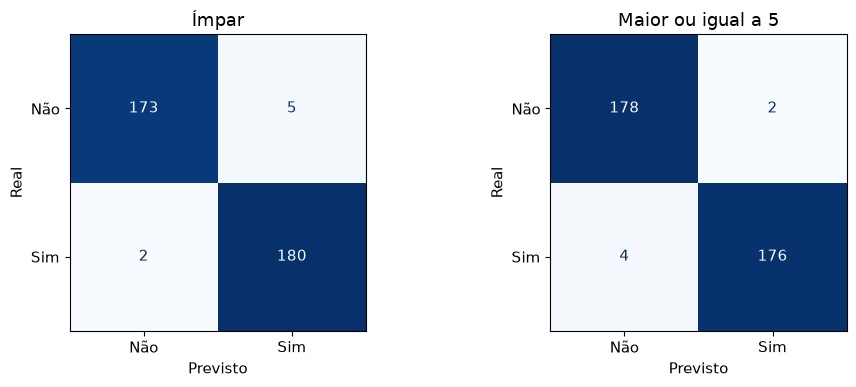

In [77]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for j, eixo in enumerate(eixos):
    ConfusionMatrixDisplay.from_predictions(
        Y_dig[idx_dig_teste, j], pred_multi_teste[:, j],
        labels=[0, 1], display_labels=['Não', 'Sim'],
        ax=eixo, cmap='Blues', colorbar=False
    )
    eixo.set_title(nomes_rotulos[j])
    eixo.set_xlabel('Previsto')
    eixo.set_ylabel('Real')

plt.tight_layout()
plt.show()

### E a classificação com múltiplas saídas?

Multirrótulo é um caso de múltiplas saídas em que cada saída é binária.
No caso mais geral, cada saída pode ter mais de duas classes: por exemplo,
prever simultaneamente a **cor** e o **tipo** de uma peça.
`MultiOutputClassifier` pode adaptar um classificador a esses alvos.

**Exercício 8.** Classifique as tarefas:
detectar spam; reconhecer uma espécie de flor; atribuir temas a uma notícia;
prever a cor e o tipo de uma peça. Descreva como seria `y` em cada caso.

## 6. Avaliar além da acurácia: desbalanceamento, limiares e curvas

Agora vamos relacionar três decisões: qual erro medir, como a proporção de
classes afeta a leitura das métricas e como transformar escores em classes.

### 6.1. Desbalanceamento em dados sintéticos

`make_classification` permite controlar o problema. Criaremos aproximadamente
95% de negativos e 5% de positivos. Esse é um conjunto artificial, sem
interpretação de domínio para os atributos.

Compare três configurações: um Dummy, uma regressão logística comum e
outra que dá mais peso à classe rara. Usaremos o conjunto de **validação**
para observar os efeitos dessa mudança nas métricas. Esses resultados
servem à comparação; uma avaliação final exigiria um teste reservado.

In [78]:
X_des, y_des = make_classification(
    n_samples=2000, n_features=10, n_informative=5, n_redundant=2,
    weights=[0.95, 0.05], flip_y=0, class_sep=1.0, random_state=SEMENTE
)
X_des_treino, X_des_val, y_des_treino, y_des_val = train_test_split(
    X_des, y_des, test_size=0.30, stratify=y_des, random_state=SEMENTE
)

modelos_des = {
    'Sempre majoritária': DummyClassifier(strategy='most_frequent'),
    'Logística': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'Logística com pesos': make_pipeline(
        StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=2000)
    ),
}

resultados_des = []
for nome, modelo in modelos_des.items():
    modelo.fit(X_des_treino, y_des_treino)
    previsao = modelo.predict(X_des_val)
    resultados_des.append({'modelo': nome, **metricas_binarias(y_des_val, previsao)})

display(pd.DataFrame(resultados_des).set_index('modelo'))

,acurácia,precisão,recall,especificidade,F1,acurácia balanceada
modelo,,,,,,
Sempre majoritária,0.950,0.000,0.0,1.000,0.000,0.500
Logística,0.947,0.000,0.0,0.996,0.000,0.498
Logística com pesos,0.748,0.142,0.8,0.746,0.241,0.773


**Exercício 9.** Por que a resposta constante consegue 95% de acurácia?
Dar mais peso à classe rara melhorou todas as métricas? `class_weight`
modifica o treinamento, enquanto o limiar modifica a decisão depois do treino.
Nenhuma dessas mudanças garante melhora em todas as métricas.

### 6.2. Curvas ROC e precisão–recall

#### Passo 1. Um escore, vários limiares possíveis

Uma matriz de confusão descreve as decisões de um classificador para **uma
regra de decisão**. Se mudarmos o limiar, as classes previstas podem mudar,
mesmo que o modelo e os escores continuem exatamente iguais.

Uma curva mostra o que acontece ao percorrer vários limiares. Cada ponto
representa uma escolha, e não uma nova rodada de treinamento.

Vamos usar oito exemplos fictícios: **três positivos e cinco negativos**.
O escore indica quanto o classificador favorece a classe positiva. Neste
exemplo ele varia entre 0 e 1, mas construir essas curvas não exige que seja
uma probabilidade calibrada. A regra será: **prever 1 se escore ≥ limiar**.

In [79]:
real_curvas = np.array([1, 0, 1, 0, 1, 0, 0, 0])
escore_curvas = np.array([0.95, 0.85, 0.75, 0.60, 0.55, 0.40, 0.30, 0.10])

display(
    pd.DataFrame({
        'exemplo': list('ABCDEFGH'),
        'classe real': real_curvas,
        'escore para positivo': escore_curvas,
        'previsão com limiar 0.7': (escore_curvas >= 0.7).astype(int),
    }),
)

,exemplo,classe real,escore para positivo,previsão com limiar 0.7
0,A,1,0.95,1
1,B,0,0.85,1
2,C,1,0.75,1
3,D,0,0.60,0
4,E,1,0.55,0
5,F,0,0.40,0
6,G,0,0.30,0
7,H,0,0.10,0


#### Passo 2. Do limiar às contagens

Com limiar **0,7**, os exemplos A, B e C são previstos como positivos.
A e C são positivos reais: temos **2 VP**. B é negativo: temos **1 FP**.
O positivo E fica de fora: **1 FN**. Os quatro negativos restantes são VN.

Portanto, recall = `2/3`, precisão = `2/3` e taxa de falsos positivos = `1/5`.
Vamos repetir a conta para outros limiares. O limiar 1,01 é maior que todos
os escores e faz o modelo prever todos como negativos; o limiar 0 faz prever
todos como positivos.

In [80]:
linhas_curvas = []
for limiar in [1.01, 0.9, 0.8, 0.7, 0.5, 0.0]:
    previsao = (escore_curvas >= limiar).astype(int)
    vn, fp, fn, vp = confusion_matrix(real_curvas, previsao, labels=[0, 1]).ravel()
    linhas_curvas.append({
        'limiar': limiar, 'VP': vp, 'FP': fp, 'FN': fn, 'VN': vn,
        'recall (TPR)': vp / (vp + fn),
        'taxa de falsos positivos (FPR)': fp / (fp + vn),
        'precisão': vp / (vp + fp) if vp + fp else np.nan,
    })

tabela_curvas = pd.DataFrame(linhas_curvas).set_index('limiar')
display(tabela_curvas)

,VP,FP,FN,VN,recall (TPR),taxa de falsos positivos (FPR),precisão
limiar,,,,,,,
1.01,0,0,3,5,0.000,0.0,NaN
0.90,1,0,2,5,0.333,0.0,1.000
0.80,1,1,2,4,0.333,0.2,0.500
0.70,2,1,1,4,0.667,0.2,0.667
0.50,3,2,0,3,1.000,0.4,0.600
0.00,3,5,0,0,1.000,1.0,0.375


#### Passo 3. ROC: encontrar positivos versus alarmar negativos

ROC vem de *Receiver Operating Characteristic*. Os eixos são:

- **Horizontal: taxa de falsos positivos (FPR).** Dos negativos reais,
  que fração foi anunciada como positiva?
- **Vertical: recall ou taxa de verdadeiros positivos (TPR).** Dos positivos
  reais, que fração foi encontrada?

$$\mathrm{FPR}=\frac{FP}{FP+VN}=1-\mathrm{especificidade},\qquad
\mathrm{TPR}=\frac{VP}{VP+FN}=\mathrm{recall}.$$

**FPR não é 1 − precisão:** os denominadores são diferentes. FPR olha para
todos os negativos reais; precisão olha para todas as previsões positivas.

Com limiar 0,7, marcamos o ponto **(0,2; 0,667)**: alarmamos 20% dos negativos
e encontramos aproximadamente 67% dos positivos. O ponto ideal fica no
canto superior esquerdo: FPR = 0 e recall = 1.

Ao reduzir o limiar, mais exemplos entram no grupo previsto como positivo.
Recall e FPR não diminuem. Os extremos são **(0, 0)**, ninguém positivo,
e **(1, 1)**, todos positivos. A diagonal indica a referência de uma ordenação
aleatória em expectativa; uma realização finita não precisa cair exatamente nela.

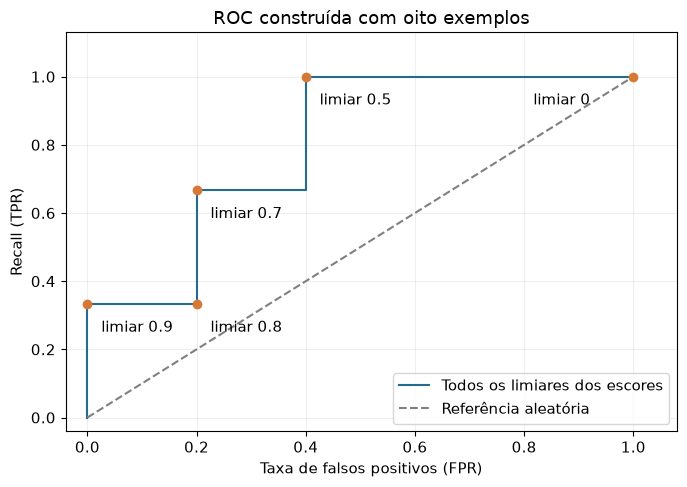

In [81]:
fpr_ex, tpr_ex, limiares_roc_ex = roc_curve(real_curvas, escore_curvas, drop_intermediate=False)
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_ex, tpr_ex, color='#246B8E', label='Todos os limiares dos escores')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Referência aleatória')

for limiar in [0.9, 0.8, 0.7, 0.5, 0.0]:
    ponto = tabela_curvas.loc[limiar]
    x, y = ponto['taxa de falsos positivos (FPR)'], ponto['recall (TPR)']
    ax.scatter(x, y, color='#D77936', zorder=3)
    deslocamento = (-72, -20) if limiar == 0 else (10, -20)
    ax.annotate(f'limiar {limiar:g}', (x, y), xytext=deslocamento, textcoords='offset points')

ax.set(xlabel='Taxa de falsos positivos (FPR)', ylabel='Recall (TPR)',
       title='ROC construída com oito exemplos', xlim=(-0.04, 1.08), ylim=(-0.04, 1.13))
ax.legend(loc='lower right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Passo 4. Precisão–recall: encontrar positivos versus acertar os alarmes

Usamos os **mesmos escores e os mesmos limiares**, mas mudamos os eixos:

- **Horizontal: recall.** Quantos dos positivos reais encontramos?
- **Vertical: precisão.** Quantos dos alarmes emitidos estavam corretos?

$$\mathrm{Precisão}=\frac{VP}{VP+FP}.$$

Com limiar 0,7, o ponto agora é **(0,667; 0,667)**. São as mesmas decisões
do ponto destacado na ROC, vistas por outra pergunta. Aqui, o canto ideal
é o superior direito: recall = 1 e precisão = 1.

Observe a tabela: ao passar de 0,9 para 0,8, adicionamos um falso positivo,
sem encontrar outro positivo. A precisão cai de 1 para 0,5. Ao passar para
0,7, encontramos outro positivo e a precisão sobe para 2/3. Portanto,
**reduzir o limiar não obriga a precisão a cair a cada passo**.

Quando todos são previstos como positivos, recall = 1 e precisão = `3/8`,
a proporção positiva. Essa proporção é uma referência para uma seleção
aleatória sem informação sobre a classe, em expectativa. Uma curva de
precisão–recall costuma ser mais útil quando fica acima dessa referência.

Quando ninguém é previsto positivo, a precisão é indefinida: por isso há
`NaN` na tabela. O scikit-learn acrescenta à curva o ponto convencional
**recall = 0, precisão = 1**, sem limiar associado. Ele permite desenhar a
curva, mas não demonstra que o modelo acertou algum alarme.

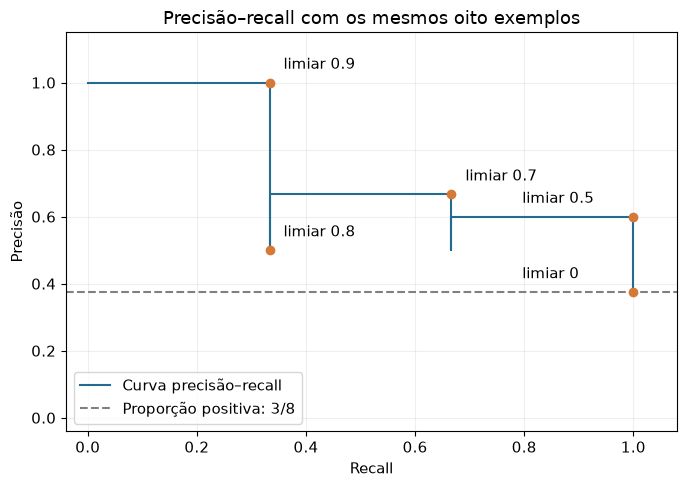

In [82]:
prec_ex, rec_ex, limiares_pr_ex = precision_recall_curve(real_curvas, escore_curvas)
fig, ax = plt.subplots(figsize=(7, 5))
ax.step(rec_ex, prec_ex, where='post', color='#246B8E', label='Curva precisão–recall')
ax.axhline(real_curvas.mean(), ls='--', color='gray', label='Proporção positiva: 3/8')

for limiar in [0.9, 0.8, 0.7, 0.5, 0.0]:
    ponto = tabela_curvas.loc[limiar]
    x, y = ponto['recall (TPR)'], ponto['precisão']
    ax.scatter(x, y, color='#D77936', zorder=3)
    deslocamento = (-80, 10) if limiar in [0.0, 0.5] else (10, 10)
    ax.annotate(f'limiar {limiar:g}', (x, y), xytext=deslocamento, textcoords='offset points')

ax.set(xlabel='Recall', ylabel='Precisão', title='Precisão–recall com os mesmos oito exemplos',
       xlim=(-0.04, 1.08), ylim=(-0.04, 1.15))
ax.legend(loc='lower left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Passo 5. Como resumir as curvas: ROC-AUC e AP

**ROC-AUC** é a área sob a curva ROC. Uma interpretação é a chance de um
positivo sorteado receber escore maior que um negativo sorteado, contando
empates como meio acerto. No nosso exemplo, há `3 × 5 = 15` pares possíveis.
O positivo A supera os cinco negativos; C supera quatro; E supera três.
São **12/15 = 0,8** pares corretamente ordenados.

AUC = 1 indica ordenação perfeita nesta amostra; AUC = 0,5 é a referência
aleatória em expectativa. **AUC = 0,8 não significa 80% de acurácia**, e a
métrica não informa qual limiar usar nem se as probabilidades estão calibradas.

**AP (*average precision*)** resume a curva precisão–recall. É uma média das
precisões ponderada pelo quanto o recall avança. Neste exemplo sem empates,
cada novo positivo acrescenta 1/3 ao recall. Nas posições dos três positivos,
as precisões são 1, 2/3 e 3/5:

$$\mathrm{AP}=\frac{1}{3}\left(1+\frac{2}{3}+\frac{3}{5}\right)\approx0{,}756.$$

AP não é a média simples das precisões da tabela de limiares, nem a área
obtida por interpolação trapezoidal. Valores maiores indicam melhor resultado,
mas a proporção positiva precisa entrar na interpretação. ROC-AUC e AP
resumem aspectos diferentes; comparar seus números diretamente não elege
uma “melhor curva”.

In [83]:
display(
    pd.Series(
        {
            'ROC-AUC: calculada pelos 15 pares': 12 / 15,
            'ROC-AUC: scikit-learn': roc_auc_score(real_curvas, escore_curvas),
            'AP: calculada pelos avanços de recall': (1 + 2/3 + 3/5) / 3,
            'AP: scikit-learn': average_precision_score(real_curvas, escore_curvas),
        },
        name='Resumo do exemplo',
    ),
)

ROC-AUC: calculada pelos 15 pares        0.800
ROC-AUC: scikit-learn                    0.800
AP: calculada pelos avanços de recall    0.756
AP: scikit-learn                         0.756
Name: Resumo do exemplo, dtype: float64

#### Passo 6. Por que olhar precisão–recall quando os positivos são raros?

Imagine o mesmo ponto de operação: **recall de 80% e FPR de 10%**.
Vamos manter essas taxas e mudar apenas as quantidades de positivos e negativos.
É uma comparação de contagens hipotéticas, não um novo treinamento.

In [84]:
cenarios = []
for nome, positivos, negativos in [('Classes equilibradas', 100, 100), ('Positivos raros', 100, 9900)]:
    vp, fp = int(0.8 * positivos), int(0.1 * negativos)
    cenarios.append({
        'cenário': nome, 'positivos reais': positivos, 'negativos reais': negativos,
        'VP': vp, 'FP': fp, 'recall': vp / positivos,
        'FPR': fp / negativos, 'precisão': vp / (vp + fp),
    })
display(pd.DataFrame(cenarios).set_index('cenário'))

,positivos reais,negativos reais,VP,FP,recall,FPR,precisão
cenário,,,,,,,
Classes equilibradas,100,100,80,10,0.8,0.1,0.889
Positivos raros,100,9900,80,990,0.8,0.1,0.075


Nos dois cenários, o ponto da ROC é **(0,1; 0,8)**. No primeiro, a precisão
é aproximadamente 88,9%; no segundo, 7,5%. Com muitos negativos, uma pequena
fração deles pode produzir muitos falsos alarmes. A precisão torna isso visível.

Isso não torna a ROC incorreta: ela responde a outra pergunta. Consulte
também as contagens de erros e a proporção das classes. Ao comparar modelos,
use os mesmos dados de avaliação; mudanças nessa proporção podem alterar
a precisão e a AP mesmo sem mudança na capacidade de ordenar as classes.

#### Passo 7. Aplicando ao Breast Cancer

Agora voltamos às probabilidades da regressão logística treinada no bloco 2
e avaliadas na **validação**. Vamos marcar os limiares 0,05, 0,5 e 0,95 nas
duas curvas e comparar as decisões associadas a cada um deles.

Observe a sequência: `predict_proba` fornece os escores; `roc_curve` e
`precision_recall_curve` percorrem seus valores para calcular as curvas.
Se passássemos apenas as classes de `predict`, perderíamos a maior parte
das alternativas de limiar e das informações de ordenação.

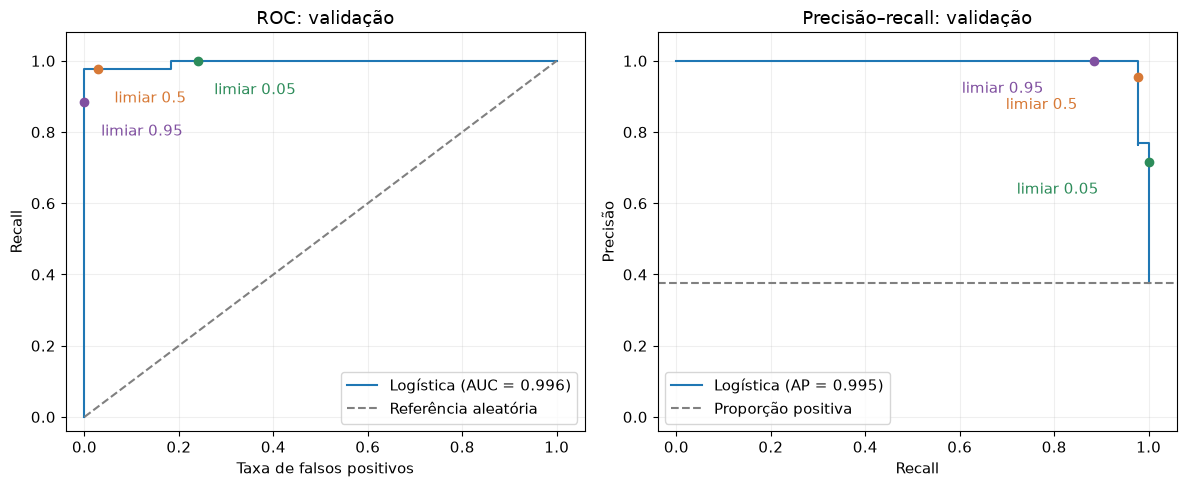

,positivos previstos,precisão,recall,especificidade
limiar,,,,
0.05,60,0.717,1.000,0.761
0.50,44,0.955,0.977,0.972
0.95,38,1.000,0.884,1.000


In [85]:
fpr_bin, tpr_bin, _ = roc_curve(y_bin_val, prob_bin_val)
prec_bin, rec_bin, _ = precision_recall_curve(y_bin_val, prob_bin_val)
auc_bin = roc_auc_score(y_bin_val, prob_bin_val)
ap_bin = average_precision_score(y_bin_val, prob_bin_val)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
eixos[0].plot(fpr_bin, tpr_bin, label=f'Logística (AUC = {auc_bin:.3f})')
eixos[0].plot([0, 1], [0, 1], '--', color='gray', label='Referência aleatória')
eixos[0].set(xlabel='Taxa de falsos positivos', ylabel='Recall', title='ROC: validação')
eixos[1].step(rec_bin, prec_bin, where='post', label=f'Logística (AP = {ap_bin:.3f})')
eixos[1].axhline(y_bin_val.mean(), ls='--', color='gray', label='Proporção positiva')
eixos[1].set(xlabel='Recall', ylabel='Precisão', title='Precisão–recall: validação')

for limiar, cor in zip([0.05, 0.5, 0.95], ['#2D8C5A', '#D77936', '#8050A0']):
    medidas = tabela_limiar.loc[limiar]
    x_roc, y_roc = 1 - medidas['especificidade'], medidas['recall']
    x_pr, y_pr = medidas['recall'], medidas['precisão']
    eixos[0].scatter(x_roc, y_roc, color=cor, zorder=3)
    eixos[1].scatter(x_pr, y_pr, color=cor, zorder=3)
    eixos[0].annotate(f'limiar {limiar:g}', (x_roc, y_roc),
                      xytext=(12, -24), textcoords='offset points', color=cor)
    eixos[1].annotate(f'limiar {limiar:g}', (x_pr, y_pr),
                      xytext=(-95, -23), textcoords='offset points', color=cor)
for eixo in eixos:
    eixo.set_xlim(-0.04, 1.06)
    eixo.set_ylim(-0.04, 1.08)
    eixo.grid(alpha=0.2)

eixos[0].legend(loc='lower right')
eixos[1].legend(loc='lower left')
plt.tight_layout()
plt.show()
display(tabela_limiar[['positivos previstos', 'precisão', 'recall', 'especificidade']])

#### O que levar das curvas para uma decisão?

Uma curva com bom desempenho oferece opções de limiar, mas a escolha depende
do objetivo. Se a prioridade for encontrar positivos, procure um recall alto
e examine quantos falsos alarmes isso produz. Se houver capacidade limitada
para verificar alarmes, observe também precisão e quantidade de previsões positivas.

Essa escolha pertence à **validação**. O teste serve para avaliar a regra já
escolhida. Nenhuma das duas curvas determina sozinha os custos dos erros.

**Exercício 10.** No exemplo de oito casos, encontre nas duas curvas os pontos
correspondentes ao limiar 0,7. Quais contagens geraram esses pontos? Por que
o valor horizontal mudou de uma curva para a outra?

**Exercício 11.** No Breast Cancer, suponha que precisamos atingir
recall de pelo menos 95%. Entre os três limiares exibidos, quais atendem a essa
condição na validação? Qual deles tem maior precisão? Isso garante o mesmo
recall em novos dados?

## 7. Discussão final

1. Qual é a unidade de observação e o alvo de cada problema?
2. Qual erro interessa mais em cada aplicação? Que métrica o revela?
3. O modelo supera uma regra simples que ignora os atributos?
4. Em qual conjunto foram feitas as escolhas?
5. Uma diferença pequena, em poucos exemplos, sustenta declarar um vencedor?

Para investigar quanto os resultados dependem da divisão dos dados,
podemos usar validação cruzada **nos dados de desenvolvimento**, mantendo
um teste reservado. A média e a variação entre partições ajudam a avaliar
essa dependência. A escolha da métrica continua ligada ao objetivo da tarefa.

### Referências

- [Datasets incluídos no scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html).
- [Descrição original do Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).
- [Regressão logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
- [Definição de F1 e tipos de média](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).
- [Métricas de avaliação](https://scikit-learn.org/stable/modules/model_evaluation.html).
- [Average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).
- [Construção da curva ROC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html).
- [Construção da curva precisão–recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html).
- [Multiclasse, multirrótulo e múltiplas saídas](https://scikit-learn.org/stable/modules/multiclass.html).
- [Prevenção de vazamento de dados](https://scikit-learn.org/stable/common_pitfalls.html).